In [1]:
import msprime
from demography import DemographicTopology

In [2]:
## Defining Topology
dem = DemographicTopology(['a', 'admix', 'b', 'c'])

dem.add_admixture_event('admix', 'admixPa1', 'admixPa2') # Admixture event: from Admix to Admixpa1 and Admixpa2
dem.add_merge_event('a', 'admixPa1', 'aAdmix')  # Merge event: from A and Admixpa1 to Aadmix
dem.add_merge_event('b', 'admixPa2', 'bAdmix')
dem.add_merge_event('aAdmix', 'bAdmix', 'subAnc')
dem.add_merge_event('subAnc', 'c', 'anc')

matrices, events, admixture_map = dem.get_topology_matrix_representation()
print(matrices)


[Event 1] Admixture: admix -> admixPa1 & admixPa2
[Event 2] Merge: a & admixPa1 -> aAdmix
[Event 3] Merge: b & admixPa2 -> bAdmix
[Event 4] Merge: aAdmix & bAdmix -> subAnc
[Event 5] Merge: subAnc & c -> anc
[array([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 1., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.]]), array([[0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
     

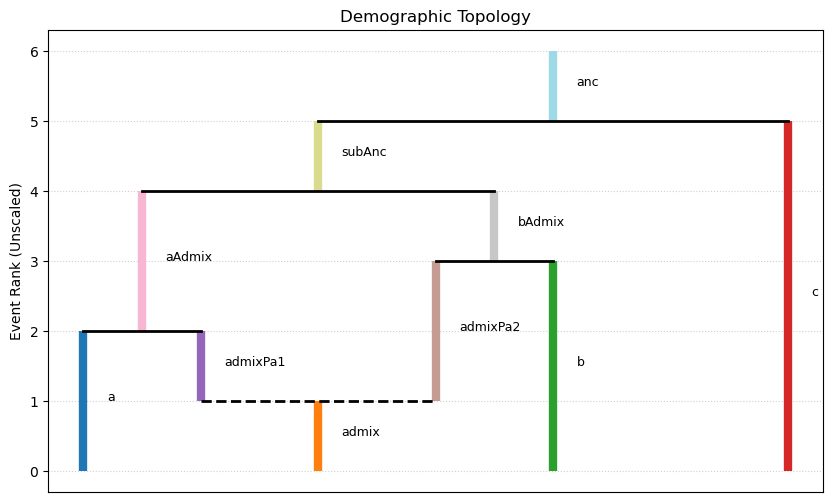

In [3]:
# Under scale = False, you can plot the graph without knowing the parameters. 
dem.plot_demography(scale = False)

In [4]:
# Effective Population Sizes
dem.set_node_ne('a', 5000)
dem.set_node_ne('b', 5000)
dem.set_node_ne('c', 5000)
dem.set_node_ne('admix', 2000)
dem.set_node_ne('admixPa1', 2000)
dem.set_node_ne('admixPa2', 2000)
dem.set_node_ne('aAdmix', 2000)
dem.set_node_ne('bAdmix', 2000)
dem.set_node_ne('subAnc', 5000)
dem.set_node_ne('anc', 10000)

dem.set_admixture_parameters('admix',100, 0.75, 'admixPa1')
dem.set_merge_time('aAdmix', 300)
dem.set_merge_time('bAdmix', 1000)
dem.set_merge_time('subAnc',1500)
dem.set_merge_time('anc', 3000)
dem.finalize_root()

[Finalize] Set anc time_end to infinity.


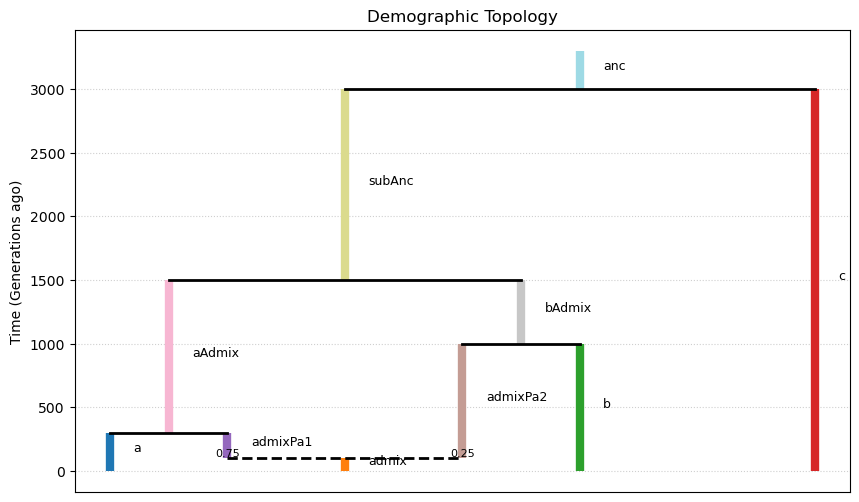

In [5]:
# This plot is sclaed by true time
dem.plot_demography(scale = True)

In [6]:
# For simulation block, first translate to msprime format
from simulation_methods import to_msprime_demography

msp = to_msprime_demography(dem)
msp.debug()

In [8]:
# This block output the pruned snp frequencies table
from simulation_methods import simulate_msprime, simulate_snp_pruning

mts = simulate_msprime(dem, sequence_length = 1e8, samples_per_pop = {'a': 20, 'b': 20, 'c': 20, 'admix': 20})

ids, freq_array = simulate_snp_pruning(
    mts,
    dem,
    temporal_folder = './plink_output',
    cutoff_time = 3000
)

Running: plink --vcf plink_output/snp_ts.vcf --make-bed --out plink_output/snp_ts --double-id --allow-extra-chr --silent
Running: plink --bfile plink_output/snp_ts --indep-pairwise 100 5 0.2 --out plink_output/pruned --allow-extra-chr --silent
LD pruning complete. Kept 5312 SNPs.
